In [3]:
import shap
import joblib
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Charger le modèle sauvegardé
rf_model = joblib.load('../models/rf_model.pkl')
scaler   = joblib.load('../models/scaler.pkl')

print("✅ Modèle chargé")

c:\Users\pc\Desktop\PredictIQ\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Modèle chargé


In [4]:
# Recharger les données
DATA_PATH = r'C:\Users\pc\Desktop\PredictIQ\Data Set'
col_names = ['unit_id', 'cycle', 'op1', 'op2', 'op3'] + \
            [f's{i}' for i in range(1, 22)]

train = pd.read_csv(os.path.join(DATA_PATH, 'train_FD001.txt'),
                    sep='\s+', header=None, names=col_names)

max_cycles = train.groupby('unit_id')['cycle'].max().reset_index()
max_cycles.columns = ['unit_id', 'max_cycle']
train = train.merge(max_cycles, on='unit_id')
train['RUL'] = train['max_cycle'] - train['cycle']
train.drop('max_cycle', axis=1, inplace=True)

useless = ['s1', 's5', 's10', 's16', 's18', 's19']
useful  = [s for s in [f's{i}' for i in range(1, 22)] if s not in useless]
features = ['cycle'] + useful

X = pd.DataFrame(scaler.transform(train[features]), columns=features)
print("✅ Données prêtes")

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
C:\Users\pc\AppData\Local\Temp\ipykernel_1252\2666332695.py:7: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+', header=None, names=col_names)


✅ Données prêtes


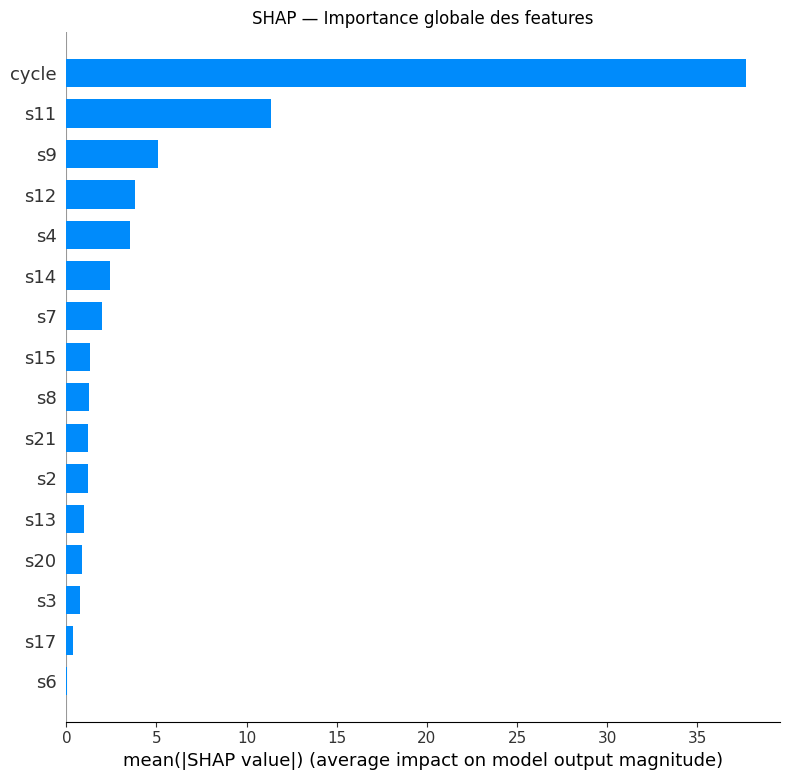

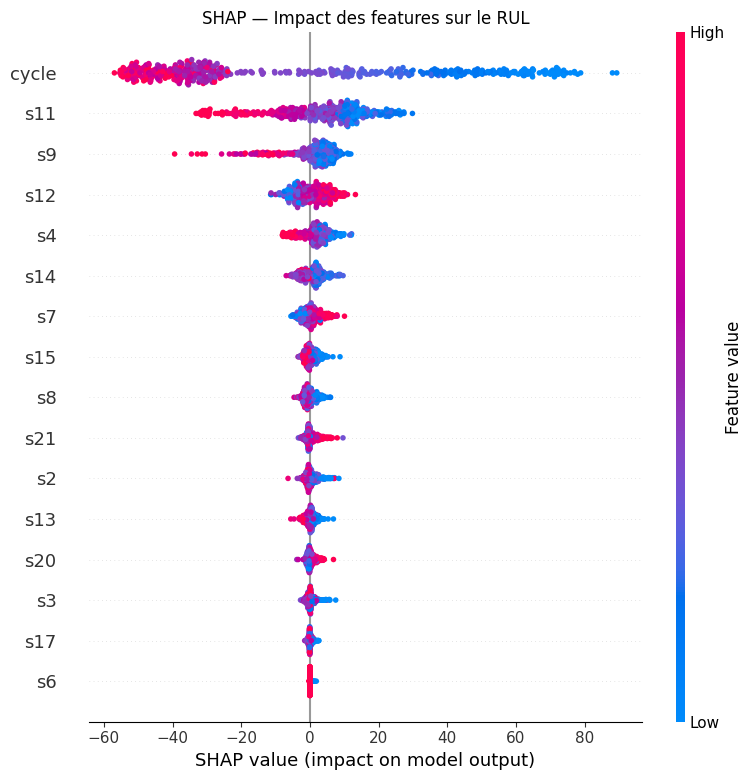

✅ SHAP terminé !


In [5]:
# SHAP — échantillon de 500 lignes pour la rapidité
sample = X.sample(500, random_state=42)

explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(sample)

# Graphique 1 — Importance globale (barres)
shap.summary_plot(shap_values, sample, plot_type='bar', show=False)
plt.title('SHAP — Importance globale des features')
plt.tight_layout()
plt.savefig('../models/shap_importance.png', dpi=150)
plt.show()

# Graphique 2 — Beeswarm plot (impact de chaque feature)
shap.summary_plot(shap_values, sample, show=False)
plt.title('SHAP — Impact des features sur le RUL')
plt.tight_layout()
plt.savefig('../models/shap_beeswarm.png', dpi=150)
plt.show()

print("✅ SHAP terminé !")